--- Training model with width: 20 ---
Epoch [500/1000], Loss: 0.001584
Epoch [1000/1000], Loss: 0.000074
--- Training model with width: 50 ---
Epoch [500/1000], Loss: 0.000695
Epoch [1000/1000], Loss: 0.000085
--- Training model with width: 100 ---
Epoch [500/1000], Loss: 0.000714
Epoch [1000/1000], Loss: 0.000104
--- Training model with width: 1000 ---
Epoch [500/1000], Loss: 0.008361
Epoch [1000/1000], Loss: 0.000920


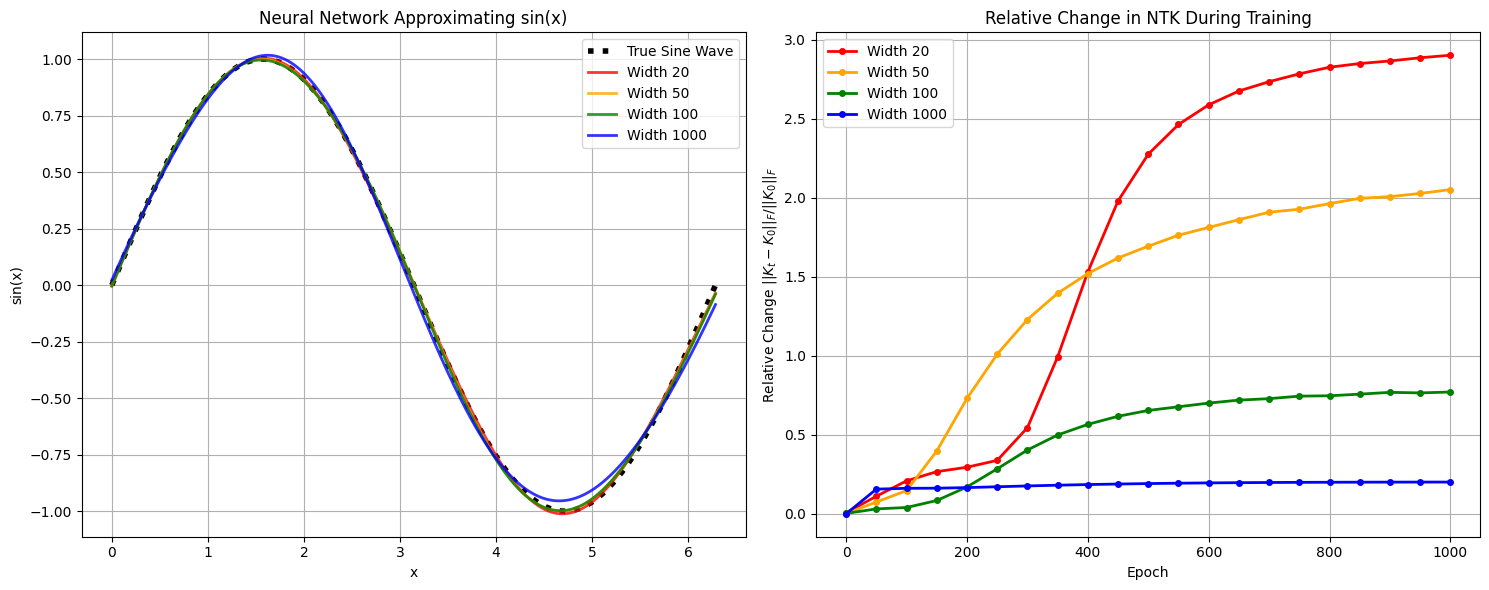

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.func import functional_call, vmap, jacrev
import math
import matplotlib.pyplot as plt

# 1. Prepare the Data
x = torch.linspace(0, 2 * math.pi, 2000).view(-1, 1)
y = torch.sin(x)

# Smaller subset for efficient NTK calculation
x_ntk = torch.linspace(0, 2 * math.pi, 50).view(-1, 1)

# 2. Define the Parametrized Architecture
class SineApproximator(nn.Module):
    def __init__(self, width):
        super(SineApproximator, self).__init__()
        # Width is now dynamically set
        self.network = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )

    def forward(self, x):
        return self.network(x)

# 3. Define the NTK Computation Function
def compute_ntk(model, x_data):
    """Computes the empirical NTK for the current state of the model."""
    params = dict(model.named_parameters())

    def fnet_single(p, x_in):
        out = functional_call(model, p, (x_in.unsqueeze(0),))
        return out.squeeze(0)

    jac_fn = jacrev(fnet_single)
    vmap_jac_fn = vmap(jac_fn, in_dims=(None, 0))
    jacobians = vmap_jac_fn(params, x_data)

    J_list = []
    for param_name, jac in jacobians.items():
        J_list.append(jac.view(x_data.shape[0], -1))

    J = torch.cat(J_list, dim=1)
    return J @ J.T

# 4. Setup Experiment Loop
widths = [20, 50, 100, 1000]
epochs = 1000

# Dictionaries to store results for plotting
results_ntk_changes = {}
results_epochs_tracked = {}
results_predictions = {}

for width in widths:
    print(f"--- Training model with width: {width} ---")
    model = SineApproximator(width)

    # Calculate the initial NTK
    K_0 = compute_ntk(model, x_ntk).detach()
    norm_K_0 = torch.norm(K_0, p='fro')

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    ntk_changes = []
    epochs_tracked = []

    # Train the Model
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(x)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()

        # Track NTK change every 50 epochs
        if epoch % 50 == 0 or epoch == epochs - 1:
            K_t = compute_ntk(model, x_ntk).detach()
            diff_norm = torch.norm(K_t - K_0, p='fro')
            relative_change = (diff_norm / norm_K_0).item()

            ntk_changes.append(relative_change)
            epochs_tracked.append(epoch)

        if (epoch + 1) % 500 == 0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.6f}')

    # Save results for this width
    results_ntk_changes[width] = ntk_changes
    results_epochs_tracked[width] = epochs_tracked

    # Get final predictions
    model.eval()
    with torch.no_grad():
        results_predictions[width] = model(x).detach()

# 5. Visualize the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['red', 'orange', 'green', 'blue']

# Plot 1: The Function Approximations
ax1.plot(x.numpy(), y.numpy(), label='True Sine Wave', color='black', linewidth=4, linestyle=':')
for idx, width in enumerate(widths):
    ax1.plot(x.numpy(), results_predictions[width].numpy(),
             label=f'Width {width}', color=colors[idx], alpha=0.8, linewidth=2)
ax1.set_title('Neural Network Approximating sin(x)')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)')
ax1.legend()
ax1.grid(True)

# Plot 2: The NTK Evolutions
for idx, width in enumerate(widths):
    ax2.plot(results_epochs_tracked[width], results_ntk_changes[width],
             label=f'Width {width}', color=colors[idx], marker='o', markersize=4, linewidth=2)
ax2.set_title('Relative Change in NTK During Training')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Relative Change $||K_t - K_0||_F / ||K_0||_F$')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

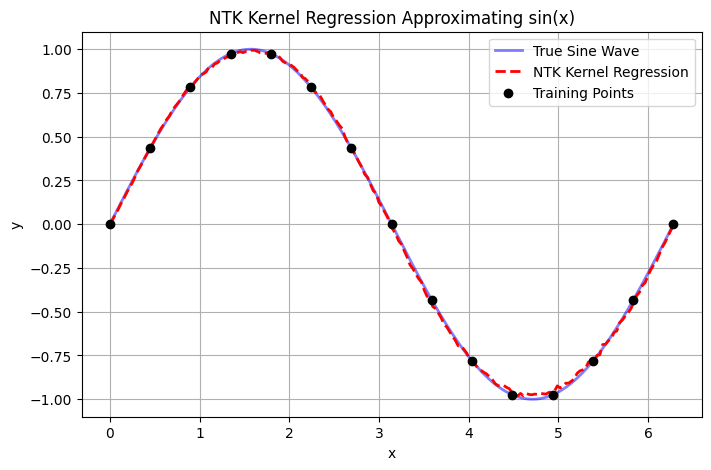

In [ ]:
import torch
import torch.nn as nn
from torch.func import functional_call, vmap, jacrev
import math
import matplotlib.pyplot as plt

# 1. Define the same architecture
class SineApproximator(nn.Module):
    def __init__(self):
        super(SineApproximator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 100),
            nn.Tanh(),
            nn.Linear(100, 1)
        )
    def forward(self, x):
        return self.network(x)

# Initialize a completely untrained model
untrained_model = SineApproximator()
params = dict(untrained_model.named_parameters())

# 2. Prepare Train and Test Data
# We use a small training set (e.g., 15 points) to make the regression clearly visible
x_train = torch.linspace(0, 2 * math.pi, 15).view(-1, 1)
y_train = torch.sin(x_train)

# We use a dense test set to plot the smooth curve predicted by the kernel
x_test = torch.linspace(0, 2 * math.pi, 200).view(-1, 1)
y_test_true = torch.sin(x_test)

# 3. Define the Jacobian extraction function (reusable)
def compute_jacobian(x_data, model, model_params):
    def fnet_single(p, x):
        out = functional_call(model, p, (x.unsqueeze(0),))
        return out.squeeze(0)

    jac_fn = jacrev(fnet_single)
    vmap_jac_fn = vmap(jac_fn, in_dims=(None, 0))

    jacobians = vmap_jac_fn(model_params, x_data)

    J_list = []
    for param_name, jac in jacobians.items():
        J_list.append(jac.view(x_data.shape[0], -1))

    return torch.cat(J_list, dim=1)

# 4. Compute the Jacobians
J_train = compute_jacobian(x_train, untrained_model, params)
J_test = compute_jacobian(x_test, untrained_model, params)

# 5. Compute the Kernel Matrices
# K_train_train: Shape (N_train, N_train)
K_train_train = J_train @ J_train.T

# K_test_train: Shape (N_test, N_train)
K_test_train = J_test @ J_train.T

# 6. Perform Kernel Ridge Regression
ridge_lambda = 1e-4  # Small regularization term
I = torch.eye(K_train_train.shape[0])

# Solve the linear system: (K + lambda*I) * alpha = y_train
# alpha has shape (N_train, 1)
alpha = torch.linalg.solve(K_train_train + ridge_lambda * I, y_train)

# Calculate the final predictions for the test set
y_pred_ntk = K_test_train @ alpha

# 7. Visualize the NTK Regression Output
plt.figure(figsize=(8, 5))
plt.plot(x_test.numpy(), y_test_true.numpy(), label='True Sine Wave', color='blue', linewidth=2, alpha=0.5)
plt.plot(x_test.numpy(), y_pred_ntk.detach().numpy(), label='NTK Kernel Regression', color='red', linestyle='dashed', linewidth=2)
plt.scatter(x_train.numpy(), y_train.numpy(), color='black', label='Training Points', zorder=5)

plt.title('NTK Kernel Regression Approximating sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()